# Evaluating a machine learning model

Three ways to evaluate Scikit-learn models:
1. Estimator `score` method
2. The `scoring` parameter
3. Problem specific metric functions

## 0. Train Models

To avoid making X, y over and over again in classification and regression problem examples ahead, let's define two functions- one to extract X and y values in Classification dataset (Heart disease) and the other one for regression dataset (House data). 

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing


def get_classification_X_y(data_path="data/heart-disease.csv", target_var="target"):
    df = pd.read_csv(data_path)
    X = df.drop(target_var, axis=1)
    y = df[target_var]
    return X, y


def get_regression_X_y(data_path=None, target_var=None):
    if not data_path:
        return fetch_california_housing(as_frame=True, return_X_y=True)
    elif data_path and target_var:
        return get_classification_X_y(data_path=data_path, target_var=target_var)

### 0.1 Train a Classification Model

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X, y = get_classification_X_y()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train_clf, y_train_clf)

RandomForestClassifier()

### 0.2 Train a Regression Model

In [3]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X, y = get_regression_X_y()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y)

reg = RandomForestRegressor()
reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor()

## 1. Using the `score` method

### 1.1 Classification

Returns the mean accuracy on the given test data and labels.

In [4]:
clf.score(X_test_clf, y_test_clf)

0.8524590163934426

### 1.2 Regression 

Returns the coefficient of determination of the prediction.

![r_squared_error](./img/r_squared_err.png)

In [5]:
reg.score(X_test_reg, y_test_reg)

0.8064162802437568

## 2. Evaluating a model using the `scoring` parameter

### Example: Apply on a Classification Problem

In [6]:
from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X, y = get_classification_X_y()

X_train, X_test, y_train, y_test = train_test_split(X, y)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

Let's look at the score method first

In [7]:
clf.score(X_test, y_test)

0.8289473684210527

Now look at the cross validation score

In [8]:
cross_val_score(clf, X, y, cv=5)
# cv=5 means 5-fold cross-validation.

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

But what and how does it work?

[Here's](https://youtu.be/cdZZyF1GGn4?si=UHcdoOFjkG_EhE5_&t=266) the answer:

![cross-validation](./img/cross-val.png)

# Evaluating a Classificaion Model


See the [docs](https://scikit-learn.org/stable/modules/model_evaluation.html)!

1. **Accuracy**
2. **Area under ROC curve**
3. **Confusion Matrix**
4. **Classification report**


## 1. Accuracy

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X, y = get_classification_X_y()

clf = RandomForestClassifier()

cross_val_score(clf, X, y)

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

A note: cross_val_score **does not fit** the estimator. See [here](https://stackoverflow.com/questions/42263915/using-sklearn-cross-val-score-and-kfolds-to-fit-and-help-predict-model)

## 2. Area under ROC

It is also known as AUC - Area under ROC curve.

ROC stands for "Receiver Operating Characteristics".

AUC measures the enire two-dimensional area underneath the entire ROC curve from (0, 0) to (1, 1). Kinda like integration.

Okay Let's break it down:

First, let's look at the terminologies -

In our dataset, our classification model is trying to predict two classes either heart disease present or not. In other words, we are predicting two classes it's either False(0) [heart deases absent] or Postive(1) [heart disease present]. Based on all the possible cases in this predictions we can observe the following -

| Observation | Meaning | Description | Result |
|------|---------|-------------|--------|
| TP | True Positive | Predicted 1 and It's actually 1 | Correctly (Truely) predicted 1 |
| FP | False Positive | Predicted 1 but It's acutally 0 | Incorrectly (Falsely) predicted 1 |
| TN | True Negative | Predicted 0 and It's actually 0 | Correctly (Truely) predicted 0 |
| FN | False Negative | Predicted 0 but It's actually 1 | Incorrectly (Falsely) predicted 0 |

Looking at the table above we can also say that:

Total Positive Cases = TP + FN

Total Negative Cases = TN + FP

Now Let's define more terminologies:

**TPR** -> True Positive Rate. Rate of Truely/Correctly predicted 1's. So, TPR defines how many correct postive results (1s') occur among all positive samples. It is a synonym for **Recall**

**FPR** -> False Positive Rate. Rate of Falsely/Incorrectly predited 1's. So, FPR defines how many incorrect positive results occur among all negative samples.

Thus,

$TPR = \frac{TP}{TP + FN}$

$FPR = \frac{FP}{FP + TN}$

Here's a TPR vs. FPR at different classification thresholds. In other words ROC curve (source: [Google](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc))

![TPR-vs-FPR](https://developers.google.com/static/machine-learning/crash-course/images/ROCCurve.svg)


And here's the AUC:

![AUC](https://developers.google.com/static/machine-learning/crash-course/images/AUC.svg)

Let's do some coding now.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

X, y = get_classification_X_y()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Make predictions with probabiltiy
y_pred_prabilities = clf.predict_proba(X_test)
y_pred_prabilities[:10]

array([[0.51, 0.49],
       [0.17, 0.83],
       [0.51, 0.49],
       [0.72, 0.28],
       [0.43, 0.57],
       [0.12, 0.88],
       [0.3 , 0.7 ],
       [0.97, 0.03],
       [0.15, 0.85],
       [0.4 , 0.6 ]])

Observation: In each row, the first element is the probality of negative class and 2nd elemnet is positvie class.

We will store the positive prablities in a variable.

In [11]:
y_pred_all_postives = y_pred_prabilities[:, 1]

Why? Well, let's look at the doc string of `roc_curve` function:

Parameters:

**`y_true`**: ndarray of shape (n_samples,) True binary labels. If labels are not either {-1, 1} or {0, 1}, then pos_label should be explicitly given.

**`y_score`**: ndarray of shape (n_samples,) Target scores, can either be probability estimates of the positive class, confidence values, or non-thresholded measure of decisions (as returned by "decision_function" on some classifiers).

Thus, because of the *`y_score`* parameter, we have calculated the postive probabilites.


**The `roc_curve` Returns the following:**


***`fpr`*** : ndarray of shape (>2,)
    Increasing false positive rates such that element i is the false
    positive rate of predictions with score >= `thresholds[i]`.

***`tpr`*** : ndarray of shape (>2,)
    Increasing true positive rates such that element `i` is the true
    positive rate of predictions with score >= `thresholds[i]`.

***`thresholds`*** : ndarray of shape = (n_thresholds,)
    Decreasing thresholds on the decision function used to compute
    fpr and tpr. `thresholds[0]` represents no instances being predicted
    and is arbitrarily set to `max(y_score) + 1`.

In [12]:
# calculate fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_all_postives)

Now that we have obtained the `fpr` and `tpr`. Let's plot a ROC curve. Shall we?

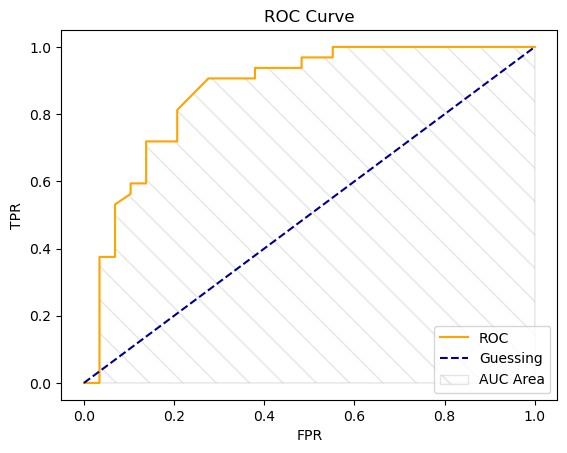

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

# Plot ROC
ax.plot(fpr, tpr, label="ROC", color="orange")

# Plot line with no predictive power (baseline)
# So, anything above this line is good, and below is bad at prediction
ax.plot([0,1], [0,1], label="Guessing", linestyle="--", color="darkblue")

# Adding the Area under ROC too!
ax.fill_between(fpr, tpr, alpha=0.2, hatch="\\", color="none", edgecolor="grey", label="AUC Area")

ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")

plt.show()

In [14]:
# Calculate the AUC Score
roc_auc_score(y_test, y_pred_all_postives)

0.8669181034482759

## 3. Confusion Matrix

A confusion matrix is a table that is used to define the performance of a classification algorithm. 

![confusion-matrix](./img/confusion-matrix.png)
*Image taken from [here](https://www.google.com/url?sa=i&url=https%3A%2F%2Fplat.ai%2Fblog%2Fconfusion-matrix-in-machine-learning%2F&psig=AOvVaw2hdgoQXbFbvkxoztuZKkyC&ust=1694201288575000&source=images&cd=vfe&opi=89978449&ved=2ahUKEwjwzJHhnZmBAxVMcmwGHUn-Bg0QjRx6BAgAEAw).*


In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Train the model real quick
X, y = get_classification_X_y()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
clf = RandomForestClassifier(random_state=1)
clf.fit(X_train, y_train)

# Produce a confusion matrix
y_pred = clf.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[24,  5],
       [ 4, 28]], dtype=int64)

What do we understand by it? Here's a break down:

| Comment | Value | Meaning |
|--------|-------|---------|
| TP | 24 | Correctly predicted 23 presence of heart disease |
|FP | 5 | Falsely predicted 3 presence of heart disease. While they are acutally absence of heart disease|
|FN | 4 | False predicted 4 absense of heart disease. While they are actually presence of heart disease|
|TN| 28 | Correctly predicted 31 cases of presence of heart disease|

---

**Bonus**: We can also take advantage of [`pd.crosstab()`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html) function to visualize this. By default, `crosstab` function, calculates the frequencies of the matched combination of rows (index) and columns. So, in this case it's similar to our confusion matrix. 

*[Chris Moffitt](https://pbpython.com/pandas-crosstab.html) has a nice article on use cases of pandas crosstab.*

In [16]:
pd.crosstab(y_test, y_pred, rownames=["Actual Values"], colnames=["Predicted Values"])

Predicted Values,0,1
Actual Values,,
0,24,5
1,4,28


Let's assume:

**0** to be **negative class** or absense of heart disease

**1** to be **positive class** or presence of heart disease

So, using common sense, 

**Observation: 1**

* The total number of actual negative classes are: $24 + 5 = 29$

* The total number of actual postive classes are: $4 + 28 = 32$

**Observation: 2**

* Thus, Total size of test sample: $29 + 32 = 61$

***Let's Try to match our calculations using code:***

**Proof of Observation 1** 

* TP and FN (Falsely predicted negative, but actually postive) adds up all the actual number of positive classes in test data.

    $\text{# postive classes} = TP + FN $
<br>

* Similarly, TN and FP (Falsely predicted positive, but actually negative) should add up to all the actual number of negative classes in test data.

    $\text{# negative classes} = TN + FP $


In [18]:
positive_class = 1
negative_class = 0

TN, FP, FN, TP = confusion_matrix(y_test, y_pred).flatten()

# Calculate num of Positive classes in test data
postive_classes_in_test_data = y_test[y_test == positive_class].size

# Calculate num of Postive classes from confusion matrix
positive_classes_in_confusion_matrix = TP + FN

postive_classes_in_test_data, positive_classes_in_confusion_matrix

(32, 32)

In [22]:
# Calculate num of Negative classes in test data
negative_classes_in_test_data = y_test[y_test == negative_class].size

# Calculate num of Negative classes from confusion matrix
negative_classes_in_confusion_matrix = TN + FP

negative_classes_in_test_data, negative_classes_in_confusion_matrix

(29, 29)

**Proof of Observation 2** 

Obviously all the numbers in the confusion_matrix should add up to the size of test data. In our case it is the variable `y_test`.

In [23]:
# size of test data according to confusion matrix
confusion_matrix(y_test, y_pred).flatten().sum()

61

In [24]:
# size of test data
y_test.size

61

Another way to visualize

In [25]:
!pip install seaborn

Text(50.722222222222214, 0.5, 'Acutal Values')

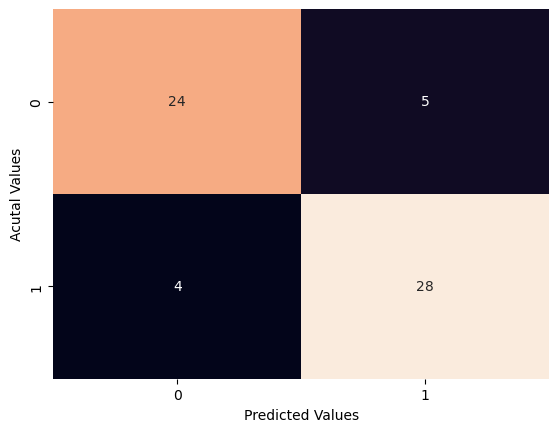

In [26]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cbar=False)
plt.xlabel("Predicted Values")
plt.ylabel("Acutal Values")

## 4. Classification Report


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



Here's a break down:

**Precision:** Percentage of correct positive predictions relative to total positive predictions. A model which produces no false positives has a precission of 1.0. So,

<p><center>
$Precision = \frac{TP}{Total\:Predicted\:Positives} \times 100\% \;= \;\frac{TP}{TP\: + \:FP}\times 100\%$
</center></p>

**Recall:** Percentage of correct positive predictions relative to total positive predictions. A model which has no false negatives has a recall of 1.0. So,

<p><center>
$Recall = \frac{TP}{Total\:Actual\:Positives} \times 100\% \;= \;\frac{TP}{TP\: + \:FN}\times 100\%$
</center></p>


**F1 Score:** A combination of precision and recall. In other words, a weighted harmonic mean of precision and recall. A perfect model achieves F1 Score of 1.0. So,

<p><center>
$F1\:Score = 2\times \frac{Precision\: \times \:Recall}{Precision\: + \:Recall } \times 100\%$
</center></p>



**Support:** The number of samples each metric was calculated on.


**Accuracy:** The total correct predictions with respect to test data(actual data). Perfect accuary is 1.0. So,

<p><center>
$Accuracy = \frac{TP\: + \:TN}{Total\:Test\:Data\:Size} \times 100\%$
</center></p>



**Macro Avg:** Short for macro average, the average precision, recall adn F1 score between classes. Macro avg doesn't take class imbalance into account, so if we do have class imbalances, we should pay attention to this metric. So,

* Macro-avg for precision:
<p><center>
$\text{Macro-Precision} = \frac{\text{Precision}_{Class\:1} \:+\: \text{Precision}_{Class\:2} \:+\: \text{Precision}_{Class\:3} + ...}{\text{Number of Classes}}$
</center></p>

* Macro-avg for recall:
<p><center>
$\text{Macro-Recall} = \frac{\text{Recall}_{Class\:1} \:+\: \text{Recall}_{Class\:2} \:+\: \text{Recall}_{Class\:3} \:+\: ...}{\text{Number of Classes}}$
</center></p>

* Macro-avg for F1-Score:
<p><center>
$\text{Macro-F1} = \frac{\text{F1}_{Class\:1} \:+\: \text{F1}_{Class\:2} \:+\: \text{F1}_{Class\:3} \:+\: ...}{\text{Number of Classes}}$
</center></p>



**Weighted avg:** Short for wighted average. The weighted avg of precision, recall and F1 score between classes. Weighted means each metric is calculated with respect to how many samples there are in each class. This metric will favour the majority class. So,

<p>

$
\text{Wieghted-Precision}
= 
\frac{
\text{Precision}_{Class\:1} \times Support_{Class\:1}
\:+\: 
\text{Precision}_{Class\:2} \times Support_{Class\:1}
\:+\: 
\text{Precision}_{Class\:3} \times Support_{Class\:1}
\:+\: ...}
{\text{Total Support}}
$

</p>


<p>

$
\text{Wieghted-Recall}
= 
\frac{
\text{Recall}_{Class\:1} \times Support_{Class\:1}
\:+\: 
\text{Recall}_{Class\:2} \times Support_{Class\:1}
\:+\: 
\text{Recall}_{Class\:3} \times Support_{Class\:1}
\:+\: ...}
{\text{Total Support}}
$

</p>


<p>

$
\text{Wieghted-F1}
= 
\frac{
\text{F1}_{Class\:1} \times Support_{Class\:1}
\:+\: 
\text{F1}_{Class\:2} \times Support_{Class\:1}
\:+\: 
\text{F1}_{Class\:3} \times Support_{Class\:1}
\:+\: ...}
{\text{Total Support}}
$

</p>




Here is an Example with imbalanced class for interpretaion.

**Classification Report Example:**

```plaintext
                precision    recall  f1-score   support

  No Disease       0.95      0.97      0.96       100
 Mild Disease      0.90      0.85      0.87        40
Severe Disease     0.89      0.91      0.90        60

    accuracy                           0.93       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.93      0.93      0.93       200
```

**Interpretation**

1. Class-wise Metrics:

    * **No Disease:** Among the predictions made for No Disease, 95% were correct (*`precision`*). 97% of actual No Disease cases were correctly predicted (*`recall`*). The `F1-score`, which is the harmonic mean of precision and recall is 96% which is close to 100%. Thre were 100 actual instances of this class (*`support`*)

    * **Mild Disease:** For the Mild Disease class, 90% of predcitions were correct (*`precision`*), but the model could identify only 85% of acutal mild disease cases. The `F1-score` is 87%. There were 40 actual instances of this class(*`support`*).

    * **Severe Disease:** 89% of the Sever Disease were correct among the predictions made.(*`precision`*). However, the model could identify 91% actual Severe Diseases (*`recall`*). The `F1-score` is 90% with 60 actual instances (*`support`*)
<br>


2. Overall Metrics:

    - **Accuracy:** Alltogether, 93% of the predictions were correct by the model.

    - **Macro Avg:** This is the unweighted average of the metric across all classes. Precision, recall, and F1-score are all 91%. This suggests that the classifier's performance is relatively consistent across classes, without a major bias towards any particular class.

    - **Wighted Avg:** This takes the size (or "support") of each class into account. The weighted averages for precision, recall, and F1-score are all 93%. Because this average is higher than the macro average, it indicates that the model performs slightly better on the larger classes (in this case, "No Disease").

<br>

**Conclusion**


The classifier seems to be performing relatively well across all classes, with a high overall accuracy of 93%. Its performance on the "No Disease" class is especially commendable, given the high precision and recall.

However, the slightly lower recall for "Mild Disease" suggests that there's some room for improvement in identifying patients with mild disease conditions. The classifier might be mistaking some "Mild Disease" cases for either "No Disease" or "Severe Disease."

The macro and weighted averages being close suggests that, while there is some class imbalance (100 instances of "No Disease" vs. 40 of "Mild Disease"), it isn't drastically affecting the classifier's performance.

*Thanks to ChatGPT*

So let's wrap up all the classification matrics:

* **Accuracy** is a good measure to start with if all classes are balanced e.g. soame amount of samples which are labelled with 0 or 1.

* **Precision** and **Recall** become more important when classes are imbalanced i.e. some classes has a significantly higher frequency than others.
    * If **False Positive** predictions are worse than false negatives, aim for higher precision.
    * If **False Negative** predictions are worse than false positives, aim for higher recall.
    
* **F1-Score** is a combination of precision and recall.

# Evaluating a Regression Model

See the [docs](https://scikit-learn.org/stable/modules/model_evaluation.html)!

1. **$R^2$ aka- Coefficient of determination**
2. **Mean Absolute Error (MAE)**
3. **Mean Squared Error (MSE)**


Let's Train a model first

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
np.random.seed(42)

X, y = get_regression_X_y()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

model = RandomForestRegressor(random_state=1)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=1)

 ## 1. $R^2$ aka- Coefficient of determination
 
 Coefficient of Determination,
 $$R^2 = 1 - \frac{SS_{residual}}{SS_{total}}$$


Where,

* $ SS_{residual} $ is the sum of squares of residuals and is given by:

$$ SS_{residual} = \sum_{i = 1}^{n} (y_i - \hat y_i) ^2 $$
Here, $y_i$ represents the actual value of the dependent variable for the $i^{th}$ observation, and $\hat y_i$ is the predicted value for the $i^{th}$ observation.

* $ SS_{total} $ is the total sum of squares and is given by:

$$ SS_{total} = \sum_{i=1}^{n} (y_i - \bar y)^2 $$
here, $\bar y $ is the mean of the observed data.

The $R^2$ value ranges between 0 and 1. An $R^2$ value of 1 implies that the regression predictions perfectly fit the data. Conversely, an $R^2$ value of 0 implies that the model does not explian any of the variation in the response variable around its mean. In machine learning, higher $R^2$ values often indicate that the model fits the data better, though caution is needed as a vary high $R^2$ might also be an indication of overfitting.

In [35]:
model.score(X_test, y_test)

0.8073706744897567